<a href="https://colab.research.google.com/github/Luppouk/Atividades-Calculo-Numerico/blob/main/atividade4/entrega_30_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Luan Groppo Viana

RA: 177103

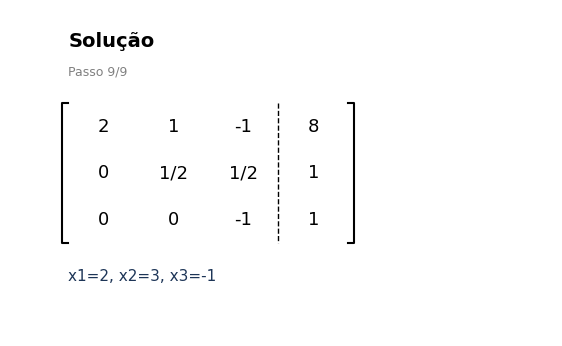

In [2]:
from fractions import Fraction
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle

A = [[2, 1, -1],
     [-3, -1, 2],
     [-2, 1, 2]]
b = [8, -11, -3]


def resolver(A, b):
    n = len(A)
    M = [[Fraction(v) for v in A[i]] + [Fraction(b[i])] for i in range(n)]
    frames = []

    def save(t, d, pivo=None, dest=None, sol=None):
        frames.append({
            "M": [l[:] for l in M],
            "t": t, "d": d, "pivo": pivo,
            "dest": dest or {},
            "sol": list(sol) if sol else []
        })

    save("Matriz inicial", "Sistema")

    for k in range(n):
        if M[k][k] == 0:
            for i in range(k + 1, n):
                if M[i][k] != 0:
                    M[k], M[i] = M[i], M[k]
                    save("Troca", f"L{k+1} ↔ L{i+1}", (k, k), {k: "#ffd59e", i: "#ffd59e"})
                    break
        if M[k][k] == 0:
            raise ValueError("Sem solução única.")

        for i in range(k + 1, n):
            if M[i][k] == 0:
                continue
            m = M[i][k] / M[k][k]
            M[i] = [M[i][j] - m * M[k][j] for j in range(n + 1)]
            save(f"Eliminação c{k+1}", f"L{i+1} = L{i+1} - ({m})·L{k+1}", (k, k), {k: "#b7e4c7", i: "#ffd59e"})

    save("Escalonada", "Fim da eliminação")

    x = [None] * n
    for i in range(n - 1, -1, -1):
        s = sum(M[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (M[i][n] - s) / M[i][i]
        parc = [(f"x{j+1}", x[j]) for j in range(n) if x[j] is not None]
        save("Substituição", f"x{i+1} = {x[i]}", (i, i), {i: "#b7e4c7"}, parc)

    save("Solução", ", ".join(f"x{i+1}={x[i]}" for i in range(n)), [(f"x{i+1}", x[i]) for i in range(n)])
    return frames


frames = resolver(A, b)
n = len(A)
W, H = 1.2, 0.8

fig, ax = plt.subplots(figsize=(7, 5))


def draw(idx):
    f = frames[idx]
    ax.clear()
    ax.set_xlim(-1, (n + 1) * W + 3.5)
    ax.set_ylim(-(n + 2) * H, 2 * H)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.text(0, 1.2 * H, f["t"], fontsize=14, fontweight="bold")
    ax.text(0, 0.6 * H, f"Passo {idx + 1}/{len(frames)}", fontsize=9, color="gray")

    for r, c in f["dest"].items():
        ax.add_patch(Rectangle((-0.1, -(r + 1) * H + 0.05), (n + 1) * W + 0.2, H - 0.1, color=c, alpha=0.8))

    if f["pivo"] and len(f["pivo"]) == 2:
        r, c = f["pivo"]
        ax.add_patch(Rectangle((c * W, -(r + 1) * H + 0.05), W, H - 0.1, fill=False, edgecolor="red", lw=2))

    for i in range(n):
        for j in range(n + 1):
            ax.text(j * W + W / 2, -(i + 0.5) * H, str(f["M"][i][j]), ha="center", va="center", fontsize=13)

    h = n * H
    xr = (n + 1) * W
    ax.plot([n * W] * 2, [0, -h], "k--", lw=1)
    for x0, d in ((-0.1, 0.1), (xr + 0.1, -0.1)):
        ax.plot([x0 + d, x0, x0, x0 + d], [0, 0, -h, -h], "k", lw=1.5)

    ax.text(0, -(n + 0.8) * H, f["d"], fontsize=11, color="#1d3557")

    if f["sol"]:
        ax.text(xr + 0.8, 0.2 * H, "Solução", fontsize=11, fontweight="bold")
        for k, (v, val) in enumerate(reversed(f["sol"])):
            ax.text(xr + 0.8, -(k + 0.5) * H, f"{v} = {val}", fontsize=11)


anim = FuncAnimation(fig, draw, frames=len(frames), interval=2000)

if __name__ == "__main__":
    anim.save("eliminacao_gauss.gif", writer=PillowWriter(fps=0.5))
    plt.show()